# Vocabulary Richness Results

This notebook builds the results section from `data/processed.db` and follows the methods discussed in `thesis/bachelor_thesis_new.pdf`: sample coverage, Good--Turing intuition, Chao1/iChao1, ACE, jackknife, Breakaway, rarefaction/extrapolation, parametric Poisson mixtures, and the completely monotone estimator of Balabdaoui and Kulagina.

Run the cells from top to bottom. Expensive model fits are controlled by flags in the setup cell.

In [ ]:
from __future__ import annotations

import math
import sqlite3
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

try:
    import seaborn as sns
    sns.set_theme(style="whitegrid", context="notebook")
except Exception:
    sns = None
    plt.style.use("default")

REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / "data" / "processed.db").exists():
    REPO_ROOT = Path.cwd().resolve().parent

DB_PATH = REPO_ROOT / "data" / "processed.db"
CODE_DIR = REPO_ROOT / "code"
sys.path.insert(0, str(CODE_DIR))

# Slow sections. Turn these on when you want the full model comparison.
RUN_BREAKAWAY_ALL = True
RUN_PARAMETRIC_MIXTURES = True

FIGSIZE = (9, 5)
DB_PATH

WindowsPath('C:/Users/frato/OneDrive/Documents/ETH/Semester6/BachelorThesis/data/processed.db')

## Load Processed Data

`corpora` contains one row per speaker/character/corpus item. `freq_counts` stores the abundance frequency counts `f_k`. `word_counts` stores the full type counts and is used for rarefaction and model-fit examples.

In [7]:
with sqlite3.connect(DB_PATH) as con:
    corpora = pd.read_sql_query(
        """
        SELECT id, name, loader, corpus_source, speaker_id, n_tokens, s_obs,
               coverage_turing, coverage_chao_jost
        FROM corpora
        WHERE n_tokens IS NOT NULL AND s_obs IS NOT NULL
        """,
        con,
    )
    freq_counts = pd.read_sql_query("SELECT corpus_id, k, f_k FROM freq_counts", con)

corpora["source"] = corpora["corpus_source"].fillna(corpora["loader"]).fillna("unknown")
corpora = corpora.loc[corpora["source"] != "corpus"].copy()

SOURCE_INFO = {
    "clapi": {"language": "French", "register": "spoken (multi-domain)"},
    "dgd": {"language": "German", "register": "spoken"},
    "bnc": {"language": "English", "register": "spoken"},
    "sbcorpus": {"language": "English", "register": "spoken"},
    "imsdb": {"language": "English", "register": "script dialogue"},
    "shakespeare": {"language": "English", "register": "literary"},
}

corpora["language"] = corpora["source"].map(lambda x: SOURCE_INFO.get(x, {}).get("language", "unknown"))
corpora["register"] = corpora["source"].map(lambda x: SOURCE_INFO.get(x, {}).get("register", "unknown"))
corpora["type_token_ratio"] = corpora["s_obs"] / corpora["n_tokens"]
corpora.head()

,id,name,loader,corpus_source,speaker_id,n_tokens,s_obs,coverage_turing,coverage_chao_jost,source,language,register,type_token_ratio
1,3,A Midsummer Nights Dream,shakespeare,NaN,NaN,16385,2974,0.897650,0.897654,shakespeare,English,literary,0.181507
2,4,Alls Well That Ends Well,shakespeare,NaN,NaN,22852,3477,0.912699,0.912701,shakespeare,English,literary,0.152153
3,5,Antony And Cleopatra,shakespeare,NaN,NaN,24147,3882,0.906075,0.906077,shakespeare,English,literary,0.160765
4,6,As You Like It,shakespeare,NaN,NaN,21554,3229,0.917185,0.917187,shakespeare,English,literary,0.149810
5,7,Coriolanus,shakespeare,NaN,NaN,27183,3977,0.916418,0.916420,shakespeare,English,literary,0.146305


## Basic Comparisons Across Languages and Sources

These tables answer the first descriptive question: how many tokens and distinct word types do we observe on average for each language/source, and how complete are those samples according to sample coverage?

In [8]:
language_summary = (
    corpora.groupby("language")
    .agg(
        n_items=("id", "count"),
        total_tokens=("n_tokens", "sum"),
        avg_tokens=("n_tokens", "mean"),
        median_tokens=("n_tokens", "median"),
        avg_observed_types=("s_obs", "mean"),
        median_observed_types=("s_obs", "median"),
        avg_type_token_ratio=("type_token_ratio", "mean"),
        avg_coverage=("coverage_turing", "mean"),
    )
    .sort_values("total_tokens", ascending=False)
)

source_summary = (
    corpora.groupby(["source", "language", "register"])
    .agg(
        n_items=("id", "count"),
        total_tokens=("n_tokens", "sum"),
        avg_tokens=("n_tokens", "mean"),
        avg_observed_types=("s_obs", "mean"),
        avg_type_token_ratio=("type_token_ratio", "mean"),
        avg_coverage=("coverage_turing", "mean"),
    )
    .sort_values("total_tokens", ascending=False)
)

display(language_summary.round(3))
display(source_summary.round(3))

,n_items,total_tokens,avg_tokens,median_tokens,avg_observed_types,median_observed_types,avg_type_token_ratio,avg_coverage
language,,,,,,,,
French,10813,160251286,14820.243,1927.0,1484.531,585.0,0.308,0.810
English,5603,9376736,1673.521,826.0,480.766,360.0,0.423,0.722
German,47,68141,1449.809,1485.0,505.106,543.0,0.359,0.778


,,,n_items,total_tokens,avg_tokens,avg_observed_types,avg_type_token_ratio,avg_coverage
source,language,register,,,,,,
clapi,French,spoken (multi-domain),10813,160251286,14820.243,1484.531,0.308,0.810
imsdb,English,script dialogue,5335,6307786,1182.340,431.578,0.426,0.721
shakespeare,English,literary,86,2701373,31411.314,3717.279,0.174,0.898
bnc,English,spoken,136,312275,2296.140,411.890,0.432,0.699
dgd,German,spoken,47,68141,1449.809,505.106,0.359,0.778
sbcorpus,English,spoken,46,55302,1202.217,338.239,0.461,0.671


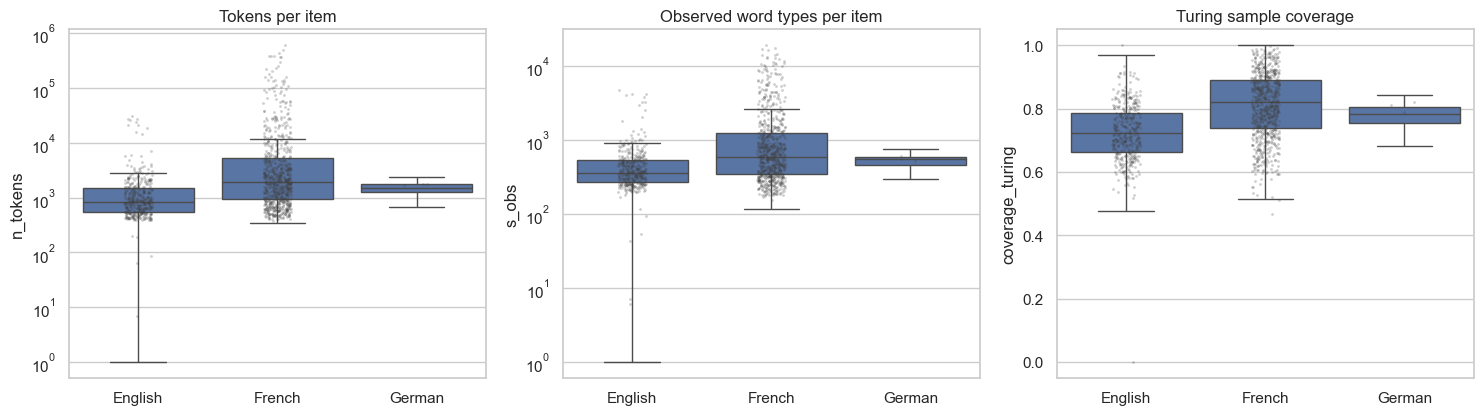

In [9]:
plot_df = corpora.copy()

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, y, title in zip(
    axes,
    ["n_tokens", "s_obs", "coverage_turing"],
    ["Tokens per item", "Observed word types per item", "Turing sample coverage"],
):
    if sns is not None:
        sns.boxplot(data=plot_df, x="language", y=y, ax=ax, showfliers=False)
        sns.stripplot(data=plot_df.sample(min(len(plot_df), 1200), random_state=1), x="language", y=y, ax=ax, color="0.25", alpha=0.25, size=2)
    else:
        plot_df.boxplot(column=y, by="language", ax=ax)
    ax.set_title(title)
    ax.set_xlabel("")
    if y in {"n_tokens", "s_obs"}:
        ax.set_yscale("log")
fig.suptitle("")
fig.tight_layout()

## Estimators

The thesis frames vocabulary estimation as species richness estimation. The observed vocabulary `S_obs` is a lower bound. The estimators below use the frequency counts `f_1, f_2, ...` to estimate the undetected vocabulary mass/count.

In [10]:
from estimators.classical import ace, chao1, ichao1, jackknife1, jackknife2
from estimators.coverage import coverage_chao_jost, coverage_turing

try:
    from estimators.breakaway import breakaway
except Exception as exc:
    breakaway = None
    print(f"Breakaway unavailable: {exc}")


def freq_dict(corpus_id: int) -> dict[int, int]:
    rows = freq_counts.loc[freq_counts["corpus_id"] == corpus_id, ["k", "f_k"]]
    return {int(k): int(v) for k, v in rows.itertuples(index=False)}


def observed_stats(freq: dict[int, int]) -> tuple[int, int]:
    s_obs = sum(freq.values())
    n = sum(k * v for k, v in freq.items())
    return s_obs, n


def bk_completely_monotone(freq: dict[int, int]) -> dict[str, float]:
    """Balabdaoui-Kulagina completely monotone estimator from the thesis."""
    s_obs, n = observed_stats(freq)
    if s_obs == 0 or n <= 1:
        return {"N_infty": np.nan, "k_n": np.nan, "cm_factor": np.nan, "cm_valid_alpha": False}

    pbar1 = freq.get(1, 0) / s_obs
    alpha_bar = 1.0 - pbar1
    threshold = (math.sqrt(2.0) - 1.0) ** 2
    if alpha_bar <= 0:
        return {"N_infty": np.nan, "k_n": np.nan, "cm_factor": np.nan, "cm_valid_alpha": False}

    k_n = max(1, int(math.floor(math.log(n) / (2.0 * math.log(math.sqrt(alpha_bar) + 1.0)))))
    alternating_sum = 0.0
    sigma2 = 0.0
    for j in range(1, k_n + 1):
        pbar_j = freq.get(j, 0) / s_obs
        c = math.comb(k_n, j)
        alternating_sum += ((-1) ** j) * c * pbar_j
        sigma2 += (c**2) * pbar_j

    cm_factor = 1.0 - alternating_sum
    n_hat = math.floor(s_obs * cm_factor) if np.isfinite(cm_factor) and cm_factor > 0 else np.nan
    return {
        "N_infty": n_hat,
        "k_n": k_n,
        "cm_factor": cm_factor,
        "cm_valid_alpha": alpha_bar >= threshold,
        "cm_sigma": math.sqrt(sigma2) if sigma2 >= 0 else np.nan,
    }


_NAN_ESTIMATE = {
    "S_obs": np.nan, "n_tokens_check": np.nan,
    "f1": np.nan, "f2": np.nan,
    "coverage_turing_calc": np.nan, "coverage_chao_jost_calc": np.nan,
    "Chao1": np.nan, "iChao1": np.nan, "ACE": np.nan,
    "Jackknife1": np.nan, "Jackknife2": np.nan,
    "N_infty": np.nan, "k_n": np.nan, "cm_factor": np.nan,
    "cm_valid_alpha": False, "cm_sigma": np.nan,
}


def estimate_one(row: pd.Series) -> dict[str, float]:
    freq = freq_dict(int(row["id"]))
    n = sum(k * v for k, v in freq.items())
    if n == 0:
        return {"id": int(row["id"]), **_NAN_ESTIMATE}
    out = {
        "id": int(row["id"]),
        "S_obs": sum(freq.values()),
        "n_tokens_check": n,
        "f1": freq.get(1, 0),
        "f2": freq.get(2, 0),
        "coverage_turing_calc": coverage_turing(freq),
        "coverage_chao_jost_calc": coverage_chao_jost(freq),
        "Chao1": chao1(freq),
        "iChao1": ichao1(freq),
        "ACE": ace(freq),
        "Jackknife1": jackknife1(freq),
        "Jackknife2": jackknife2(freq) if n > 1 else np.nan,
    }
    out.update(bk_completely_monotone(freq))
    if RUN_BREAKAWAY_ALL and breakaway is not None:
        try:
            out["Breakaway"] = breakaway(freq)["S_hat"]
        except Exception:
            out["Breakaway"] = np.nan
    return out


estimates = pd.DataFrame([estimate_one(row) for _, row in corpora.iterrows()])
results = corpora.merge(estimates, on="id", how="left")

for col in ["Chao1", "iChao1", "ACE", "Jackknife1", "Jackknife2", "N_infty"]:
    results[f"{col}_lift"] = results[col] / results["S_obs"]

results.head()

,id,name,loader,corpus_source,speaker_id,n_tokens,s_obs,coverage_turing,coverage_chao_jost,source,...,k_n,cm_factor,cm_valid_alpha,cm_sigma,Chao1_lift,iChao1_lift,ACE_lift,Jackknife1_lift,Jackknife2_lift,N_infty_lift
0,3,A Midsummer Nights Dream,shakespeare,NaN,NaN,16385,2974,0.897650,0.897654,shakespeare,...,9.0,2.691661,True,46.060832,2.012399,2.183978,3.659796,1.563853,1.970672,2.691661
1,4,Alls Well That Ends Well,shakespeare,NaN,NaN,22852,3477,0.912699,0.912701,shakespeare,...,9.0,4.142652,True,44.118754,2.142337,2.353822,3.764720,1.573745,2.003395,4.142652
2,5,Antony And Cleopatra,shakespeare,NaN,NaN,24147,3882,0.906075,0.906077,shakespeare,...,10.0,5.106904,True,75.464649,2.148172,2.357031,3.875953,1.584211,2.019781,5.106646
3,6,As You Like It,shakespeare,NaN,NaN,21554,3229,0.917185,0.917187,shakespeare,...,9.0,3.614741,True,45.938407,1.996674,2.188295,3.549137,1.552777,1.952252,3.614432
4,7,Coriolanus,shakespeare,NaN,NaN,27183,3977,0.916418,0.916420,shakespeare,...,10.0,5.607745,True,76.273470,2.094360,2.294340,3.817436,1.571264,1.993416,5.607745


In [11]:
estimator_cols = ["S_obs", "Chao1", "iChao1", "ACE", "Jackknife1", "Jackknife2", "N_infty"]

estimator_summary = (
    results.groupby(["source", "language"])[estimator_cols]
    .median()
    .sort_values("S_obs", ascending=False)
)
display(estimator_summary.round(1))

lift_cols = [c for c in results.columns if c.endswith("_lift")]
lift_summary = results.groupby(["source", "language"])[lift_cols].median().sort_index()
display(lift_summary.round(2))

,,S_obs,Chao1,iChao1,ACE,Jackknife1,Jackknife2,N_infty
source,language,,,,,,,
shakespeare,English,3471.0,7055.5,7680.0,12917.7,5456.4,6880.0,11845.0
clapi,French,568.0,1377.2,1507.5,2443.5,928.8,1200.7,2118.0
dgd,German,532.0,1269.4,1359.3,2188.3,855.8,1111.3,1952.0
sbcorpus,English,393.0,760.4,831.2,1532.8,612.3,802.9,1087.0
imsdb,English,354.0,891.8,976.4,1529.0,586.7,766.4,1337.5
bnc,English,280.5,563.4,610.3,1141.6,440.8,556.5,939.5


,,Chao1_lift,iChao1_lift,ACE_lift,Jackknife1_lift,Jackknife2_lift,N_infty_lift
source,language,,,,,,
bnc,English,2.00,2.18,3.61,1.58,1.98,3.04
clapi,French,2.17,2.37,3.92,1.61,2.06,3.43
dgd,German,2.28,2.50,4.10,1.63,2.10,3.41
imsdb,English,2.39,2.61,4.15,1.65,2.15,3.65
sbcorpus,English,2.05,2.22,3.79,1.59,2.02,3.11
shakespeare,English,2.05,2.25,3.76,1.58,2.00,3.51


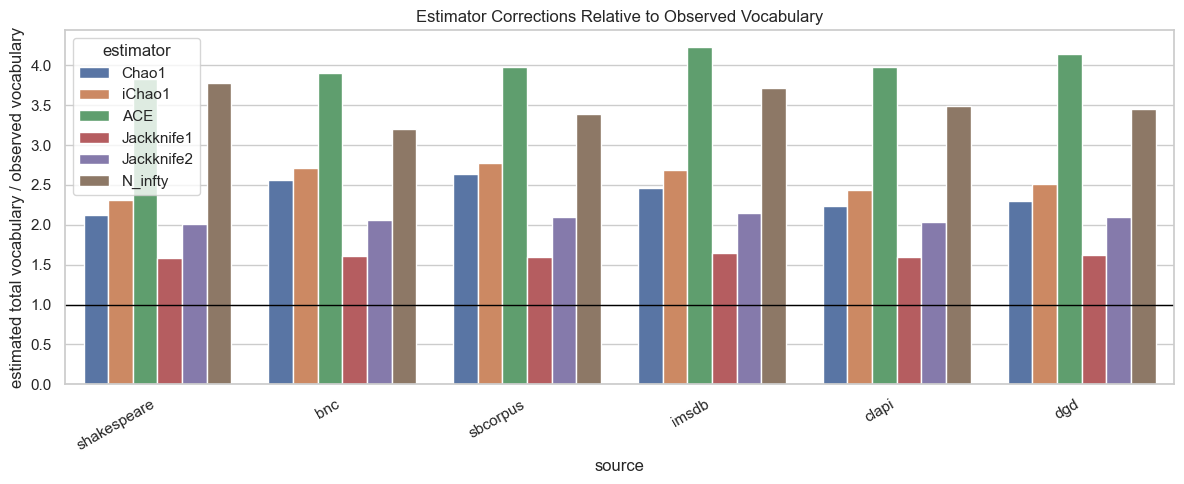

In [12]:
long_lifts = results.melt(
    id_vars=["id", "source", "language", "n_tokens", "S_obs"],
    value_vars=["Chao1_lift", "iChao1_lift", "ACE_lift", "Jackknife1_lift", "Jackknife2_lift", "N_infty_lift"],
    var_name="estimator",
    value_name="estimated_total_over_observed",
).dropna()
long_lifts["estimator"] = long_lifts["estimator"].str.replace("_lift", "", regex=False)

plt.figure(figsize=(12, 5))
if sns is not None:
    sns.barplot(data=long_lifts, x="source", y="estimated_total_over_observed", hue="estimator", errorbar=None)
else:
    long_lifts.groupby(["source", "estimator"])["estimated_total_over_observed"].median().unstack().plot(kind="bar", ax=plt.gca())
plt.axhline(1.0, color="black", linewidth=1)
plt.ylabel("estimated total vocabulary / observed vocabulary")
plt.xlabel("source")
plt.title("Estimator Corrections Relative to Observed Vocabulary")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()

## Rarefaction and Extrapolation

Rarefaction standardizes by sample size: for `m < n`, it asks how many types we would expect after drawing only `m` tokens. The extrapolation curve shown here uses the Chao-style abundance extrapolation up to `2n`, matching the intuition in the thesis.

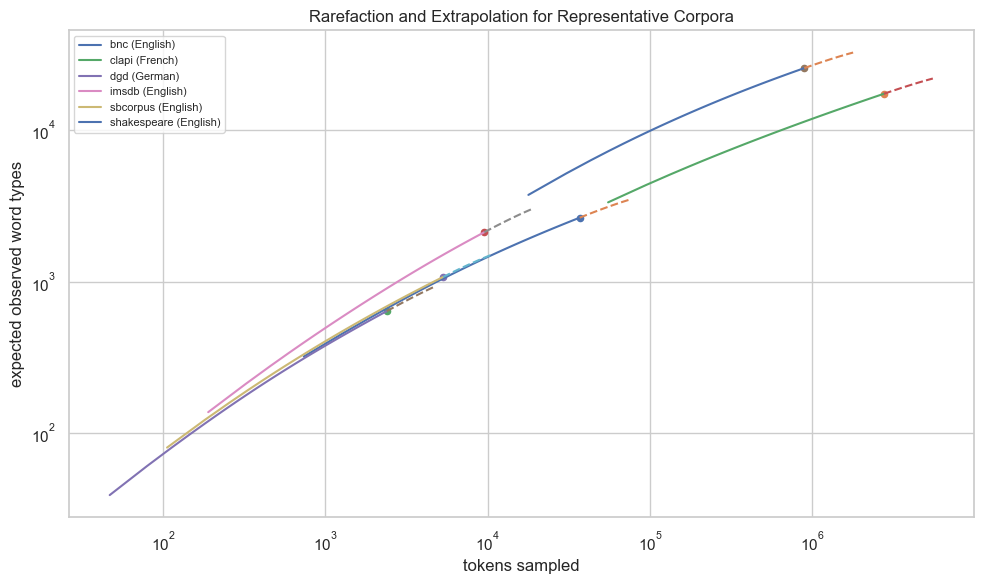

In [13]:
def load_counts(corpus_id: int) -> np.ndarray:
    with sqlite3.connect(DB_PATH) as con:
        rows = con.execute("SELECT count FROM word_counts WHERE corpus_id = ?", (int(corpus_id),)).fetchall()
    counts = np.array([count for (count,) in rows], dtype=int)
    if counts.size == 0:
        raise RuntimeError(f"No word counts found for corpus_id={corpus_id}")
    return counts


def log_choose(n, k):
    lgamma = np.vectorize(math.lgamma)
    n = np.asarray(n, dtype=float)
    k = np.asarray(k, dtype=float)
    return lgamma(n + 1) - lgamma(k + 1) - lgamma(n - k + 1)


def rarefaction_curve(counts: np.ndarray, m_values: np.ndarray) -> np.ndarray:
    n = int(counts.sum())
    richness = []
    for m in m_values:
        m = int(m)
        absent = np.zeros_like(counts, dtype=float)
        possible = n - counts >= m
        if possible.any():
            absent[possible] = np.exp(log_choose(n - counts[possible], m) - log_choose(n, m))
        richness.append(float(np.sum(1.0 - absent)))
    return np.array(richness)


def extrapolation_curve(counts: np.ndarray, m_values: np.ndarray) -> np.ndarray:
    n = int(counts.sum())
    s_obs = int(counts.size)
    values, freqs = np.unique(counts, return_counts=True)
    freq = {int(k): int(v) for k, v in zip(values, freqs)}
    f1, f2 = freq.get(1, 0), freq.get(2, 0)
    if f2 > 0:
        f0_hat = ((n - 1) / n) * f1**2 / (2 * f2)
    else:
        f0_hat = ((n - 1) / n) * f1 * (f1 - 1) / 2
    if f1 == 0 or f0_hat <= 0:
        return np.full_like(m_values, fill_value=s_obs, dtype=float)
    extra = m_values - n
    detection_rate = f1 / (n * f0_hat)
    return s_obs + f0_hat * (1.0 - (1.0 - detection_rate) ** extra)


representatives = (
    results.sort_values("n_tokens", ascending=False)
    .groupby("source")
    .head(1)
    .sort_values("source")
)

plt.figure(figsize=(10, 6))
for _, row in representatives.iterrows():
    counts = load_counts(int(row["id"]))
    n = int(counts.sum())
    m_rare = np.linspace(max(1, n // 50), n, 70, dtype=int)
    m_extra = np.linspace(n, 2 * n, 50, dtype=int)
    label = f"{row['source']} ({row['language']})"
    plt.plot(m_rare, rarefaction_curve(counts, m_rare), label=label)
    plt.plot(m_extra, extrapolation_curve(counts, m_extra), linestyle="--")
    plt.scatter([n], [counts.size], s=20)

plt.xscale("log")
plt.yscale("log")
plt.xlabel("tokens sampled")
plt.ylabel("expected observed word types")
plt.title("Rarefaction and Extrapolation for Representative Corpora")
plt.legend(fontsize=8)
plt.tight_layout()

## Breakaway Frequency-Ratio Model

Breakaway fits a rational function to consecutive frequency ratios `f_{j+1}/f_j`. The intercept at `j = 0` estimates `f_1 / f_0`, hence `f_0 = f_1 / beta_0`. This cell plots the ratio data and, when possible, the fitted curve for one representative corpus.

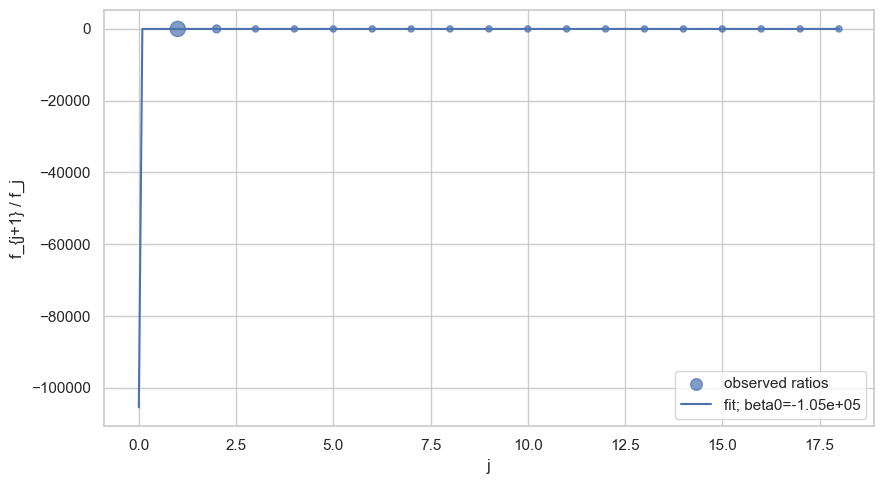

In [14]:
if breakaway is None:
    print("Breakaway is unavailable in this environment.")
else:
    from scipy.optimize import curve_fit

    def rational_curve(j, beta0, beta1, beta2, beta3):
        return (beta0 + beta1 * j) / (1.0 + beta2 * j + beta3 * j**2)

    candidate = results.loc[results["n_tokens"].between(1500, 8000)].sort_values("n_tokens").tail(1)
    if candidate.empty:
        candidate = results.sort_values("n_tokens").tail(1)
    row = candidate.iloc[0]
    freq = freq_dict(int(row["id"]))
    js, ratios, weights = [], [], []
    for j in range(1, 21):
        if freq.get(j, 0) == 0 or freq.get(j + 1, 0) == 0:
            break
        js.append(float(j))
        ratios.append(freq[j + 1] / freq[j])
        weights.append(float(freq[j]))
    js = np.array(js)
    ratios = np.array(ratios)
    weights = np.array(weights)

    plt.figure(figsize=FIGSIZE)
    plt.scatter(js, ratios, s=np.clip(weights / weights.max() * 120, 20, 120), alpha=0.7, label="observed ratios")
    if len(js) >= 4:
        beta, _ = curve_fit(rational_curve, js, ratios, p0=[max(ratios[0], 1e-4), 0, 0, 0], sigma=1 / np.maximum(weights, 1), maxfev=20000)
        grid = np.linspace(0, max(js), 200)
        plt.plot(grid, rational_curve(grid, *beta), label=f"fit; beta0={beta[0]:.3g}")
        if beta[0] > 0:
            f0_hat = freq.get(1, 0) / beta[0]
            plt.title(f"Breakaway Ratio Fit: {row['name']} | S_hat={sum(freq.values()) + f0_hat:,.0f}")
    plt.xlabel("j")
    plt.ylabel("f_{j+1} / f_j")
    plt.legend()
    plt.tight_layout()

## Parametric Poisson Mixtures

The thesis discusses Gamma--Poisson, LogNormal--Poisson, and Poisson--Inverse Gaussian mixtures. These fits can be slow and sensitive, so the fitting cell is guarded by `RUN_PARAMETRIC_MIXTURES`. Turn it on in the setup cell when you want the full parametric comparison.

In [15]:
if not RUN_PARAMETRIC_MIXTURES:
    print("Parametric mixture fitting skipped. Set RUN_PARAMETRIC_MIXTURES = True in the setup cell to run it.")
else:
    from scipy.optimize import differential_evolution
    from scipy.special import gammaln

    def negbin_pmf(x, r, mu):
        p = r / (r + mu)
        return np.exp(gammaln(r + x) - gammaln(r) - gammaln(x + 1) + r * np.log(p) + x * np.log1p(-p))

    def negbin_trunc(x, r, mu):
        p0 = (r / (r + mu)) ** r
        return negbin_pmf(x, r, mu) / (1 - p0)

    def lnp_pmf(x_arr, mu, sigma, nq=80):
        nd, wt = np.polynomial.hermite.hermgauss(nq)
        out = np.zeros(len(x_arr))
        for i, xi in enumerate(x_arr):
            lam = np.exp(mu + sigma * np.sqrt(2) * nd)
            out[i] = np.sum(wt * np.exp(int(xi) * np.log(lam + 1e-300) - lam - gammaln(int(xi) + 1))) / np.sqrt(np.pi)
        return out

    def lnp_trunc(x, mu, sigma):
        p0 = lnp_pmf(np.array([0]), mu, sigma)[0]
        return lnp_pmf(x, mu, sigma) / (1 - p0)

    def pig_logpmf(x_arr, mu, phi):
        x_arr = np.asarray(x_arr, dtype=int)
        x_max = int(np.max(x_arr))
        f0 = math.sqrt(1.0 + 2.0 * mu**2 / phi)
        r = mu**2 / (phi + 2.0 * mu**2)
        log_p = np.empty(x_max + 1)
        c = np.zeros(x_max + 1)
        p0 = math.exp((phi / mu) * (1.0 - f0))
        c[0] = p0
        log_p[0] = math.log(max(p0, 1e-300))
        for x in range(0, x_max):
            total = 0.0
            for k in range(0, x + 1):
                m = x - k
                odd_double_fact = 1.0
                for q in range(1, m + 1):
                    odd_double_fact *= 2 * q - 1
                total += math.comb(x, k) * c[k] * odd_double_fact * (r**m)
            c[x + 1] = (mu / f0) * total
            log_p[x + 1] = math.log(max(c[x + 1], 1e-300)) - math.lgamma(x + 2)
        return log_p[x_arr]

    def pig_pmf(x, mu, phi):
        return np.exp(pig_logpmf(x, mu, phi))

    def pig_trunc(x, mu, phi):
        p0 = pig_pmf(np.array([0]), mu, phi)[0]
        return pig_pmf(x, mu, phi) / (1 - p0)

    # Use the largest Shakespeare-style corpus if present, otherwise the largest corpus overall.
    row = results.loc[results["source"].eq("shakespeare")].sort_values("n_tokens", ascending=False).head(1)
    if row.empty:
        row = results.sort_values("n_tokens", ascending=False).head(1)
    row = row.iloc[0]
    counts = load_counts(int(row["id"]))
    values, freqs = np.unique(counts, return_counts=True)
    x_vals = values.astype(int)
    f_vals = freqs.astype(float)

    def fit_model(name, trunc_pmf, bounds):
        def nll(params):
            probs = trunc_pmf(x_vals, *params)
            if np.any(~np.isfinite(probs)) or np.any(probs <= 0):
                return 1e100
            return -np.sum(f_vals * np.log(probs))
        fit = differential_evolution(nll, bounds=bounds, seed=42, tol=1e-8, polish=True)
        p0 = 1 - 1 / (1 + 0)  # overwritten below per model
        return name, fit.x, fit.fun

    fits = [
        fit_model("Gamma-Poisson", negbin_trunc, [(0.005, 15), (0.01, 50)]),
        fit_model("LogNormal-Poisson", lnp_trunc, [(-8, 3), (0.1, 5)]),
        fit_model("Poisson-Inverse Gaussian", pig_trunc, [(0.01, 200), (0.01, 200)]),
    ]
    display(pd.DataFrame(fits, columns=["model", "params", "negative_log_likelihood"]))

    plt.figure(figsize=FIGSIZE)
    observed = f_vals / f_vals.sum()
    plt.scatter(x_vals, observed, s=18, label="observed zero-truncated PMF")
    grid = np.arange(1, min(80, x_vals.max()) + 1)
    for name, params, _ in fits:
        if name == "Gamma-Poisson":
            probs = negbin_trunc(grid, *params)
        elif name == "LogNormal-Poisson":
            probs = lnp_trunc(grid, *params)
        else:
            probs = pig_trunc(grid, *params)
        plt.plot(grid, probs, label=name)
    plt.xscale("log")
    plt.yscale("log")
    plt.xlabel("word count x")
    plt.ylabel("P(X=x | X>0)")
    plt.title(f"Parametric Poisson Mixture Fits: {row['name']}")
    plt.legend()
    plt.tight_layout()

Parametric mixture fitting skipped. Set RUN_PARAMETRIC_MIXTURES = True in the setup cell to run it.


## Completely Monotone Model

The later thesis section argues that, when the selected degree of monotonicity becomes large, the limiting completely monotone model is natural. The Balabdaoui--Kulagina estimator avoids choosing a finite `k` by using a data-dependent `k_n` and the zero-truncated empirical PMF.

,,k_n,cm_factor,N_infty_lift,cm_valid_alpha
source,language,,,,
bnc,English,6.0,3.039,3.039,1.0
clapi,French,7.0,3.433,3.433,1.0
dgd,German,7.0,3.407,3.407,1.0
imsdb,English,7.0,3.647,3.646,1.0
sbcorpus,English,6.0,3.109,3.109,1.0
shakespeare,English,9.0,3.510,3.510,1.0


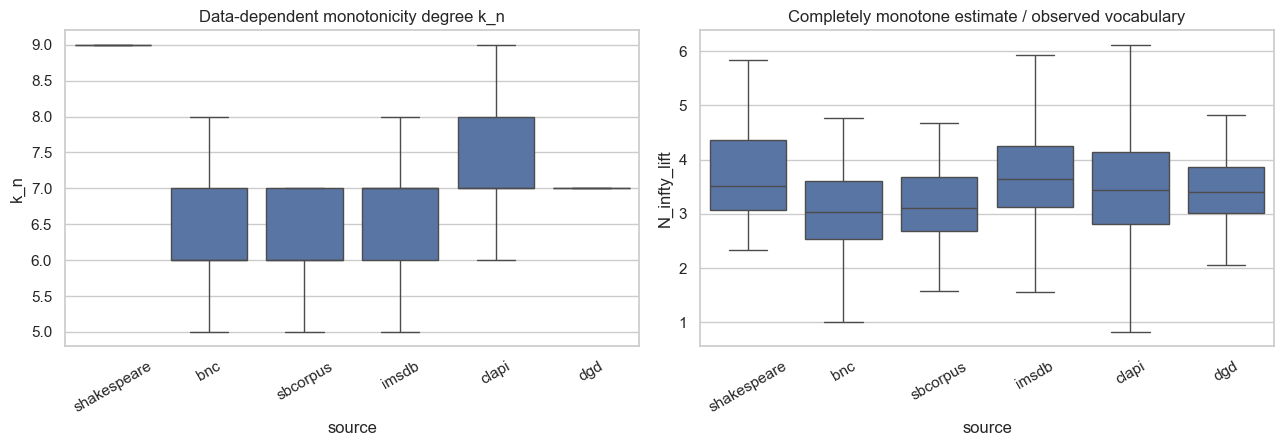

In [16]:
cm_df = results.dropna(subset=["N_infty"]).copy()
cm_df["N_infty_lift"] = cm_df["N_infty"] / cm_df["S_obs"]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
if sns is not None:
    sns.boxplot(data=cm_df, x="source", y="k_n", ax=axes[0], showfliers=False)
    sns.boxplot(data=cm_df, x="source", y="N_infty_lift", ax=axes[1], showfliers=False)
else:
    cm_df.boxplot(column="k_n", by="source", ax=axes[0])
    cm_df.boxplot(column="N_infty_lift", by="source", ax=axes[1])
axes[0].set_title("Data-dependent monotonicity degree k_n")
axes[1].set_title("Completely monotone estimate / observed vocabulary")
for ax in axes:
    ax.set_xlabel("source")
    ax.tick_params(axis="x", rotation=30)
fig.suptitle("")
fig.tight_layout()

cm_df.groupby(["source", "language"])[["k_n", "cm_factor", "N_infty_lift", "cm_valid_alpha"]].median(numeric_only=True).round(3)

## Thesis-Ready Result Tables

The final cells collect compact tables that can be copied into the results chapter: source-level descriptive statistics and source-level estimator medians.

In [17]:
table_descriptives = source_summary.reset_index().copy()
table_descriptives["avg_tokens"] = table_descriptives["avg_tokens"].round(0).astype(int)
table_descriptives["avg_observed_types"] = table_descriptives["avg_observed_types"].round(0).astype(int)
table_descriptives["avg_type_token_ratio"] = table_descriptives["avg_type_token_ratio"].round(3)
table_descriptives["avg_coverage"] = table_descriptives["avg_coverage"].round(3)
display(table_descriptives)

table_estimators = estimator_summary.reset_index().copy()
for col in estimator_cols:
    table_estimators[col] = table_estimators[col].round(0).astype("Int64")
display(table_estimators)

,source,language,register,n_items,total_tokens,avg_tokens,avg_observed_types,avg_type_token_ratio,avg_coverage
0,clapi,French,spoken (multi-domain),10813,160251286,14820,1485,0.308,0.810
1,imsdb,English,script dialogue,5335,6307786,1182,432,0.426,0.721
2,shakespeare,English,literary,86,2701373,31411,3717,0.174,0.898
3,bnc,English,spoken,136,312275,2296,412,0.432,0.699
4,dgd,German,spoken,47,68141,1450,505,0.359,0.778
5,sbcorpus,English,spoken,46,55302,1202,338,0.461,0.671


,source,language,S_obs,Chao1,iChao1,ACE,Jackknife1,Jackknife2,N_infty
0,shakespeare,English,3471,7055,7680,12918,5456,6880,11845
1,clapi,French,568,1377,1508,2444,929,1201,2118
2,dgd,German,532,1269,1359,2188,856,1111,1952
3,sbcorpus,English,393,760,831,1533,612,803,1087
4,imsdb,English,354,892,976,1529,587,766,1338
5,bnc,English,280,563,610,1142,441,556,940
